## Snapshots

In [1]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()
simulator = sire.simulationLoop(cs)
pe = cs.physicsEngine()
simulator.simDuration = sim_duration
simulator.deltaT = dt
simulator.ctrlT = ctrlt
p = parameters[0]
contactPropStr = f"{{k:{p[0]},d:{p[1]},cof:0,threshold_velocity:1e-4}}"
print(contactPropStr)
pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
model = cs.model()
displayInitJson = model.displayInitJson()
sim_result = simulator.recordsToJson()

{k:2000.0,d:0,cof:0,threshold_velocity:1e-4}


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7013/static/
4.000001221504022
(2502, 1285)
(500, 800)


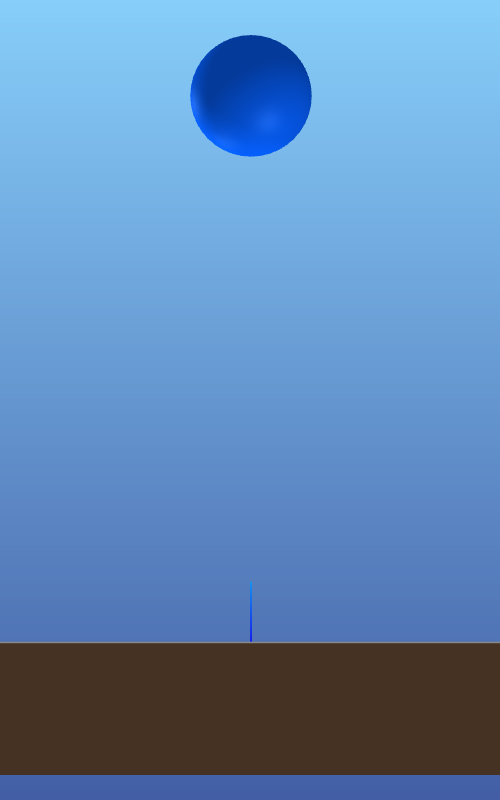

In [15]:
import meshcat
import numpy as np
from PIL import Image
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/demo/demo_python/dogRL"
# print(displayInitJson)
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
timeIndices = sim_result['timeIndex']
partpq = sim_result["partPq"]
lowerBound = 900
upperBound = sire.binarySearch(timeIndices, 2.2)
firstBounceHeight = 0
for j in range(900, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  height = partpq[j][1][2]-0.5
  if height > firstBounceHeight:
     firstBounceHeight = height
     maxIndex = j
print(firstBounceHeight)
sire.setRobotPq(model.numLinks(), vis, partpq[maxIndex])
# vis.set_cam_pos([5, 0, 6])
# vis.set_cam_target([10, 0, 10])

vis["/Cameras/default"].set_transform(np.eye(4))
# 如果通过 Meshcat 访问属性：
vis["/Cameras/default/rotated/<object>"].set_property("fov", 20) # 默认通常是 50 或 75，改小如 30 或 20
# 或者使用 zoom
# vis["/Cameras/default/rotated/<object>"].set_property("zoom", 2.0)
vis.set_cam_pos([30, 0, 0])
# vis.set_cam_target([0.5, 1., -0.5])
img = vis.get_image()
# vis.jupyter_cell()
cropped_img = img.crop((1000, 0, 1500, 800))
print(img._size)
print(cropped_img._size)
cropped_img

In [20]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()
simulator = sire.simulationLoop(cs)
pe = cs.physicsEngine()
simulator.simDuration = sim_duration
simulator.deltaT = dt
simulator.ctrlT = ctrlt
p = parameters[1]
contactPropStr = f"{{k:{p[0]},d:{p[1]},cof:0,threshold_velocity:1e-4}}"
print(contactPropStr)
pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
model = cs.model()
displayInitJson = model.displayInitJson()
sim_result = simulator.recordsToJson()

{k:200000.0,d:0,cof:0,threshold_velocity:1e-4}


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7024/static/
(2502, 1285)
(500, 800)


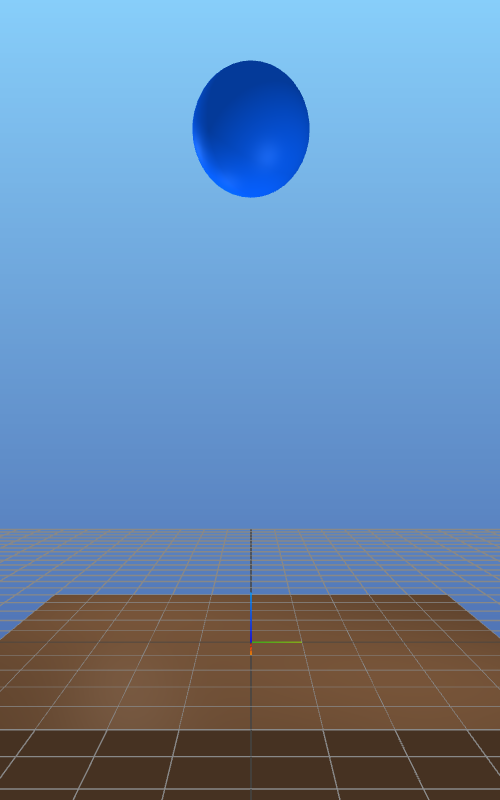

In [21]:
import meshcat
import numpy as np
from PIL import Image
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/demo/demo_python/dogRL"
# print(displayInitJson)
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
timeIndices = sim_result['timeIndex']
partpq = sim_result["partPq"]
lowerBound = 900
upperBound = sire.binarySearch(timeIndices, 2.2)
firstBounceHeight = 0
for j in range(900, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  height = partpq[j][1][2]-0.5
  if height > firstBounceHeight:
    #  print(maxIndex, firstBounceHeight)
     firstBounceHeight = height
     maxIndex = j
# print(firstBounceHeight, partpq[j][1][2]-0.5, partpq[1813][1][2]-0.5)
# partpq[j][1][2] = 4.000004929162559
# partpq[j][1][2] = 4.000001221504022
# partpq[j][1][2] = 3.9
sire.setRobotPq(model.numLinks(), vis, partpq[maxIndex])
# vis.set_cam_pos([5, 0, 6])
# vis.set_cam_target([10, 0, 10])

vis["/Cameras/default"].set_transform(np.eye(4))
vis.set_cam_pos([8, 0, 2])
# vis.set_cam_target([0.5, 1., -0.5])
img = vis.get_image()
# vis.jupyter_cell()
cropped_img = img.crop((1000, 0, 1500, 800))
print(img._size)
print(cropped_img._size)
cropped_img

In [22]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()
simulator = sire.simulationLoop(cs)
pe = cs.physicsEngine()
simulator.simDuration = sim_duration
simulator.deltaT = dt
simulator.ctrlT = ctrlt
p = parameters[2]
contactPropStr = f"{{k:{p[0]},d:{p[1]},cof:0,threshold_velocity:1e-4}}"
print(contactPropStr)
pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
model = cs.model()
displayInitJson = model.displayInitJson()
sim_result = simulator.recordsToJson()

{k:3000000.0,d:0,cof:0,threshold_velocity:1e-4}


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7026/static/


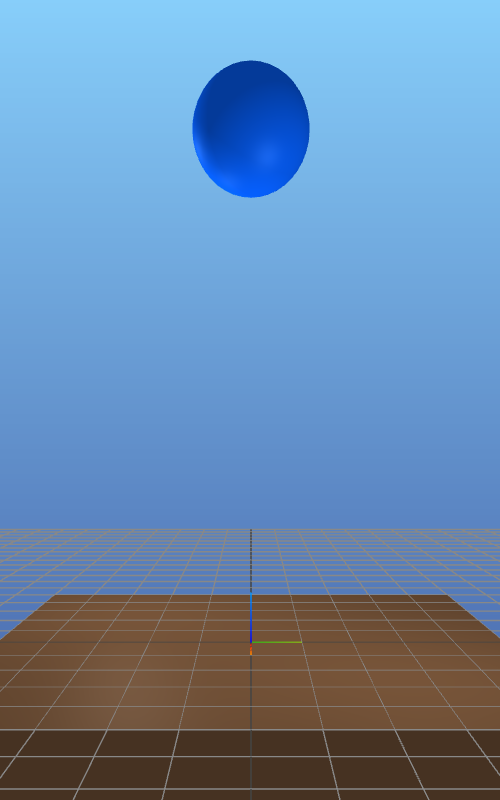

In [24]:
import meshcat
import numpy as np
from PIL import Image
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/demo/demo_python/dogRL"
# print(displayInitJson)
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
timeIndices = sim_result['timeIndex']
partpq = sim_result["partPq"]
lowerBound = 900
upperBound = sire.binarySearch(timeIndices, 2.2)
firstBounceHeight = 0
for j in range(900, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  height = partpq[j][1][2]-0.5
  if height > firstBounceHeight:
     firstBounceHeight = height
     maxIndex = j
sire.setRobotPq(model.numLinks(), vis, partpq[maxIndex])
# vis.set_cam_pos([5, 0, 6])
# vis.set_cam_target([10, 0, 10])

vis["/Cameras/default"].set_transform(np.eye(4))
vis.set_cam_pos([8, 0, 2])
# vis.set_cam_target([0.5, 1., -0.5])
img = vis.get_image()
# vis.jupyter_cell()
cropped_img = img.crop((1000, 0, 1500, 800))
cropped_img

In [25]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()
simulator = sire.simulationLoop(cs)
pe = cs.physicsEngine()
simulator.simDuration = sim_duration
simulator.deltaT = dt
simulator.ctrlT = ctrlt
p = parameters[3]
contactPropStr = f"{{k:{p[0]},d:{p[1]},cof:0,threshold_velocity:1e-4}}"
print(contactPropStr)
pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
model = cs.model()
displayInitJson = model.displayInitJson()
sim_result = simulator.recordsToJson()

{k:200000000.0,d:0,cof:0,threshold_velocity:1e-4}


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7027/static/


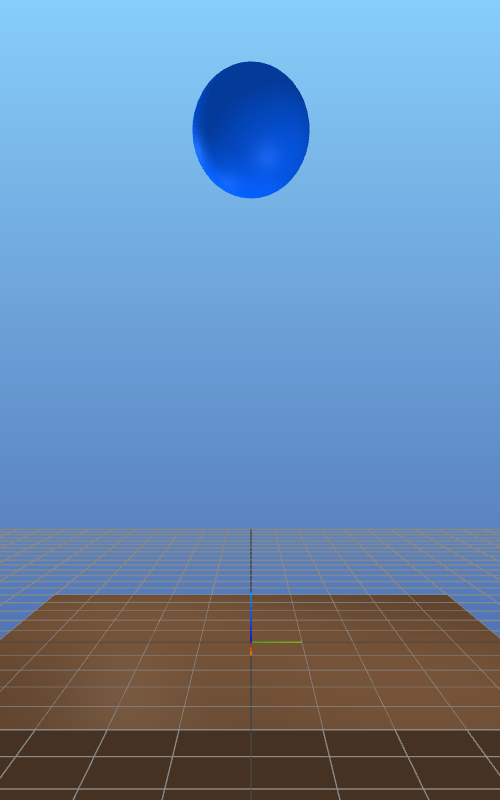

In [26]:
import meshcat
import numpy as np
from PIL import Image
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/demo/demo_python/dogRL"
# print(displayInitJson)
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
timeIndices = sim_result['timeIndex']
partpq = sim_result["partPq"]
lowerBound = 900
upperBound = sire.binarySearch(timeIndices, 2.2)
firstBounceHeight = 0
for j in range(900, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  height = partpq[j][1][2]-0.5
  if height > firstBounceHeight:
     firstBounceHeight = height
     maxIndex = j
sire.setRobotPq(model.numLinks(), vis, partpq[maxIndex])
# vis.set_cam_pos([5, 0, 6])
# vis.set_cam_target([10, 0, 10])

vis["/Cameras/default"].set_transform(np.eye(4))
vis.set_cam_pos([8, 0, 2])
# vis.set_cam_target([0.5, 1., -0.5])
img = vis.get_image()
# vis.jupyter_cell()
cropped_img = img.crop((1000, 0, 1500, 800))
cropped_img

In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
# 可选：禁用 GPU，老版本可能需要
options.add_argument('--disable-gpu')

service = Service(executable_path=r"c:\chromedriver\chromedriver.exe")
browser = webdriver.Chrome(service=service, options=options)

# 设置页面加载超时（秒）
browser.set_page_load_timeout(10)

try:
    browser.get("https://www.baidu.com")
except Exception as e:
    print(f"页面加载超时或出错: {e}")

browser.save_screenshot("snapshot.png")
browser.quit()

页面加载超时或出错: Message: timeout: Timed out receiving message from renderer: 7.995
  (Session info: chrome=146.0.7680.154)
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff7b71e3215+14585]
	chromedriver!GetHandleVerifier [0x7ff7b71e3280+145f0]
	chromedriver!(No symbol) [0x7ff7b6f4db7d]
	chromedriver!(No symbol) [0x7ff7b6f3a429]
	chromedriver!(No symbol) [0x7ff7b6f3a111]
	chromedriver!(No symbol) [0x7ff7b6f37d5b]
	chromedriver!(No symbol) [0x7ff7b6f3867f]
	chromedriver!(No symbol) [0x7ff7b6f47f1a]
	chromedriver!(No symbol) [0x7ff7b6f5ee37]
	chromedriver!(No symbol) [0x7ff7b6f6657a]
	chromedriver!(No symbol) [0x7ff7b6f38e41]
	chromedriver!(No symbol) [0x7ff7b6f5eb63]
	chromedriver!(No symbol) [0x7ff7b6ff4955]
	chromedriver!(No symbol) [0x7ff7b6f99a18]
	chromedriver!(No symbol) [0x7ff7b6f9a8f3]
	chromedriver!GetHandleVerifier [0x7ff7b74eae1d+31c18d]
	chromedriver!GetHandleVerifier [0x7ff7b74e552d+31689d]
	chromedriver!GetHandleVerifier [0x7ff7b7507f4a+3392ba]
	chromedriver!GetHandleVerifier [